In [1]:
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as ss
import scipy.special as ssp
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import pytensor.tensor.extra_ops as ate
import corner

# Truth

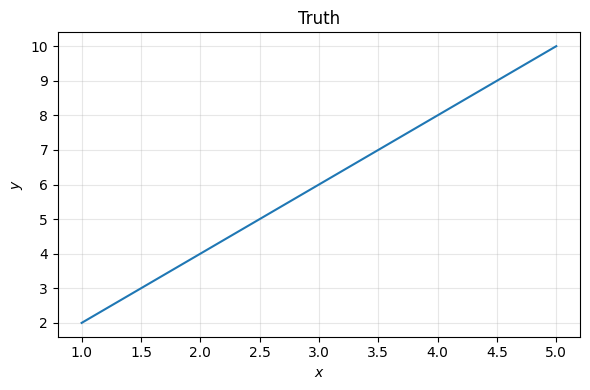

In [18]:
a = 2.0
x_true = np.linspace(1.0, 5.0, 5)
y_true = a * x_true

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_true, y_true)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Truth")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observed

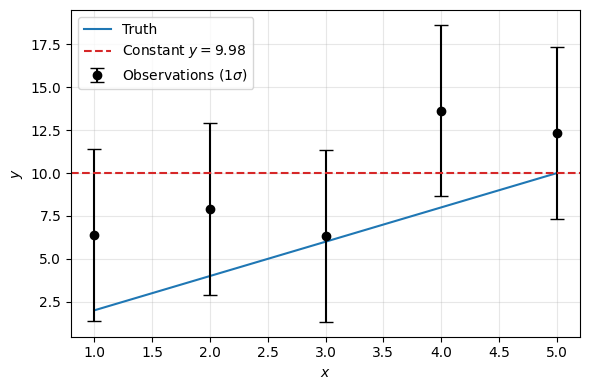

In [19]:
rng = np.random.default_rng(42)
sigma_y = 5.0

for _ in range(10000):
    y_obs = rng.normal(loc=y_true, scale=sigma_y)

    lower = np.max(y_obs - sigma_y)
    upper = np.min(y_obs + sigma_y)

    if lower < upper:
        y_constant = 0.5 * (lower + upper)
        break
        
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_true, y_true, label="Truth")
ax.errorbar(
    x_true, y_obs, yerr=sigma_y,
    fmt="o", color="black", capsize=5,
    label=r"Observations ($1\sigma$)"
)
ax.axhline(
    y_constant, color="tab:red", linestyle="--",
    label=fr"Constant $y = {y_constant:.2f}$"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Here y=constant line is consistent with almost all individual observations.

# Inference

$$
\mathcal{L}(\vec{y}^{\text{obs}}|a, \vec{x}^{\text{obs}}) = \prod_{i=1}^5 \int_{y=-\infty}^{y=\infty} dy~ \mathcal{N}(y_i^{\text{obs}}|y)~P(y|a, x_i^{\text{obs}})
$$

$$
= \prod_{i=1}^5 \int_{y=-\infty}^{y=\infty} dy~ \mathcal{N}(y_i^{\text{obs}}|y)~P(y|a, x_i^{\text{true}}) = \prod_{i=1}^5 \int_{y=-\infty}^{y=\infty} dy~ \mathcal{N}(y_i^{\text{obs}}|y)~\delta(y-a x_i^{\text{true}})
$$

$$
= \prod_{i=1}^5 ~ \mathcal{N}(y_i^{\text{obs}}|a x_i^{\text{true}})
$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [a]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


    mean     sd  hdi_5%  hdi_95%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a  2.793  0.675   1.711     3.93      0.014     0.01    2314.0    2519.0   

   r_hat  
a    1.0  


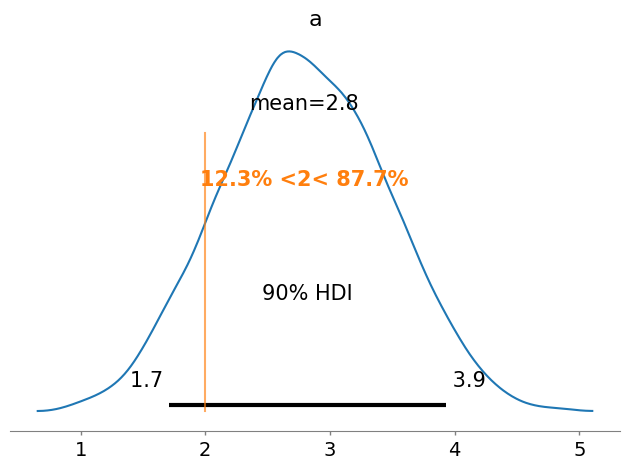

In [20]:
with pm.Model() as model:
    a_fit = pm.HalfNormal("a", sigma=5.0)

    mu_y = pm.Deterministic("mu_y", a_fit * x_true)

    # likelihood
    pm.Normal("y", mu=mu_y, sigma=sigma_y, observed=y_obs)

    trace = pm.sample(draws=2000, tune=1000, chains=4, cores=1, target_accept=0.9, random_seed=42, return_inferencedata=True)

print(az.summary(trace, var_names=["a"], hdi_prob=0.9))

az.plot_posterior(trace, var_names=["a"], hdi_prob=0.9, ref_val=a)
plt.tight_layout()
plt.show()

# Inferred a

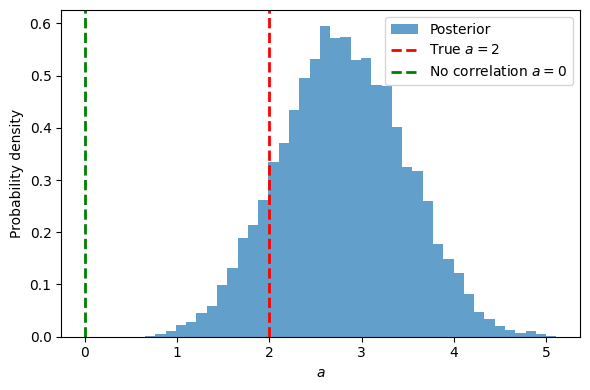

In [23]:
a_samples = trace.posterior["a"].values.flatten()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    a_samples, bins=40, density=True,
    alpha=0.7, label="Posterior"
)
ax.axvline(
    a, color="red", linestyle="--", linewidth=2,
    label=fr"True $a = {a:g}$"
)

ax.axvline(
    0, color="green", linestyle="--", linewidth=2,
    label=fr"No correlation $a = 0$"
)

ax.set_xlabel(r"$a$")
ax.set_ylabel("Probability density")
ax.legend()
plt.tight_layout()
plt.show()

Although y=constant line is consistent with all individudal observations, $a=0$ is ruled out by them. Hence hierarchical model can learn true correlation between $x$ and $y$ (given that we know the functional relation between $x$ and $y$), even if individual observations are consistent with constant y.

# PPD

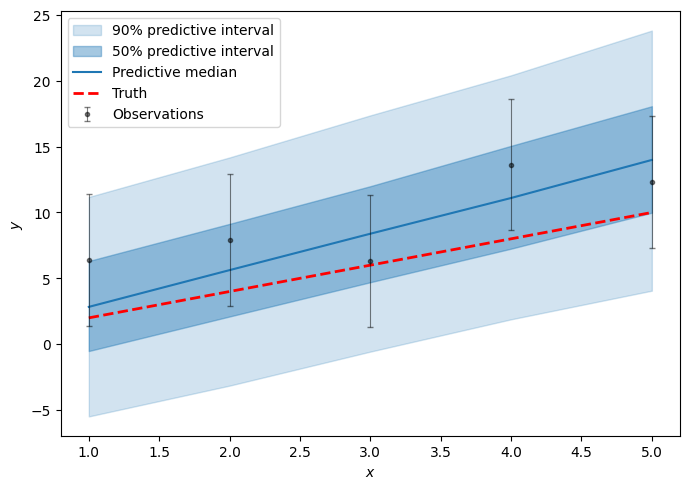

In [25]:
a_samples = trace.posterior["a"].values.flatten()
rng = np.random.default_rng(123)

y_ppd = rng.normal(
    loc=a_samples[:, None] * x_true[None, :],
    scale=sigma_y
)

q05, q25, q50, q75, q95 = np.percentile(
    y_ppd, [5, 25, 50, 75, 95], axis=0
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.fill_between(
    x_true, q05, q95,
    color="tab:blue", alpha=0.2, label="90% predictive interval"
)
ax.fill_between(
    x_true, q25, q75,
    color="tab:blue", alpha=0.4, label="50% predictive interval"
)
ax.plot(x_true, q50, color="tab:blue", label="Predictive median")
ax.plot(
    x_true, y_true,
    color="red", linestyle="--", linewidth=2, label="Truth"
)
ax.errorbar(
    x_true, y_obs, yerr=sigma_y,
    fmt="o", color="black", markersize=3,
    capsize=2, elinewidth=0.8, alpha=0.5,
    label="Observations"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()
plt.tight_layout()
plt.show()